In [1]:
# @title Importation des librairies : Faites rouler dès le début du laboratoire
%%capture
!uv pip install mycolorpy
!uv pip install ucimlrepo

from mycolorpy import colorlist as mcp
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
import numpy as np
import pandas as pd
import sklearn
from itertools import product
from ucimlrepo import fetch_ucirepo

class ErreurDansLeLaboratoire(Exception):
  def __init__(self):
    super().__init__("Cette cellule contient une partie de la solution de ce tutoriel. Veuillez ne l'ouvrir que quand vous avez fini.")

def fonction_mystère(y_test):
  k = len(np.unique(y_test))
  new_y_test = y_test.copy()
  rng = np.random.default_rng(seed=42)
  for i in range(len(y_test)):
    new_y_test[i] = (y_test[i] + rng.choice(np.unique(y_test), p=[0.8] + [0.2/(k-1)]*(k-1))) % k
  return new_y_test

Avant de commencer, je pense qu'il est important de situer le contexte. Il y a beaucoup de mésinformation en intelligence artificielle, donc il est important de bien comprendre les distinctions suivantes:

1. L'apprentissage profond est un sous-ensemble de techniques provenant de l'apprentissage automatique.

2. L'apprentissage automatique est un sous-ensemble de techniques provenant de l'intelligence artificielle.

L'intelligence artificielle est un terme (assez mal choisi) pour désigner toute méthode qui n'est pas de la programmation classique. Ainsi, en plus de l'apprentissage automatique, on y retrouve, par exemple, **l'optimisation** (convexe ou non), la **programmation par contrainte** (optimisation combinatoire et recherche opérationnelle) et **l'inférence logique** (systèmes d'experts et Prolog).

Aujourd'hui, nous nous intéresserons spécifiquement à l'apprentissage automatique plus `classique`, et nous laisserons l'apprentissage profond pour le prochain tutoriel.

Petits commentaires avant de commencer:  

*   Contrairement aux pratiques courantes, j'ai importé scikit-learn au lieu d'importer seulement les fonctions dont j'ai besoin. Cela vous permettra de mieux identifier les différentes composantes de scikit-learn.
*   J'ai caché certaines cellules, car comprendre le code qu'elles contiennent n'est pas bénéfique pour vous durant cette formation. Quand vous aurez fini l'exercice, je vous invite à aller regarder si ça vous intéresse.



# Introduction à l'apprentissage automatique

Dans ce laboratoire, nous chercherons à présenter les concepts de bases de l'apprentissage automatique. Il existe plusieurs sous-catégories d'apprentissage automatique, par exemple l'apprentissage supervisé, l'apprentissage non-supervisé, l'apprentissage par renforcement, l'apprentissage auto-supervisé, etc. Aujourd'hui, nous nous intéresserons uniquement à l'apprentissage supervisé.

On va découvrir ensemble l'apprentissage supervisé en explorant le jeu de données iris, en commençant par la visualisation du jeu de données jusqu'à la prédiction avec un arbre de décision.


# Exploration des données

En apprentissage supervisé, on travaille avec un jeu de données $S=\{(\mathbf{x}_i, y_i)\}_{i=1}^n$. $\mathbf{x}=(x_1, \ldots, x_d)$ est un vecteur de caractéristiques (*features*) réelles, discrètes ou catégorielles. L'étiquette (*label* ou *target*) $y$ peut représenter une classe, par exemple $\{-1, +1\}$ en classification binaire ou $\{1,2,3,4\}$ en classification multi-classe, ou une valeur réelle, soit $y \in \mathbb{R}$.

On va chercher à apprendre une fonction $f$ qui prend en entrée un vecteur $\mathbf{x}$ et qui prédit une étiquette $y$. On va entraîner le prédicteur $f$ sur le jeu de données $S$ pour apprendre à prédire le mieux possible les données.

On s'intéresse aujourd'hui au jeu de données *iris*. Lors de la collecte de données, ils ont pris quatre mesures de trois types de fleurs différentes, soit l'iris versicolor, l'iris setosa et l'iris virginica. Les quatres mesures vont être utilisées comme caractéristiques et on va utiliser le type d'iris comme étiquette.

 Un exemple de ces trois types d'iris est fournie ci-dessous.

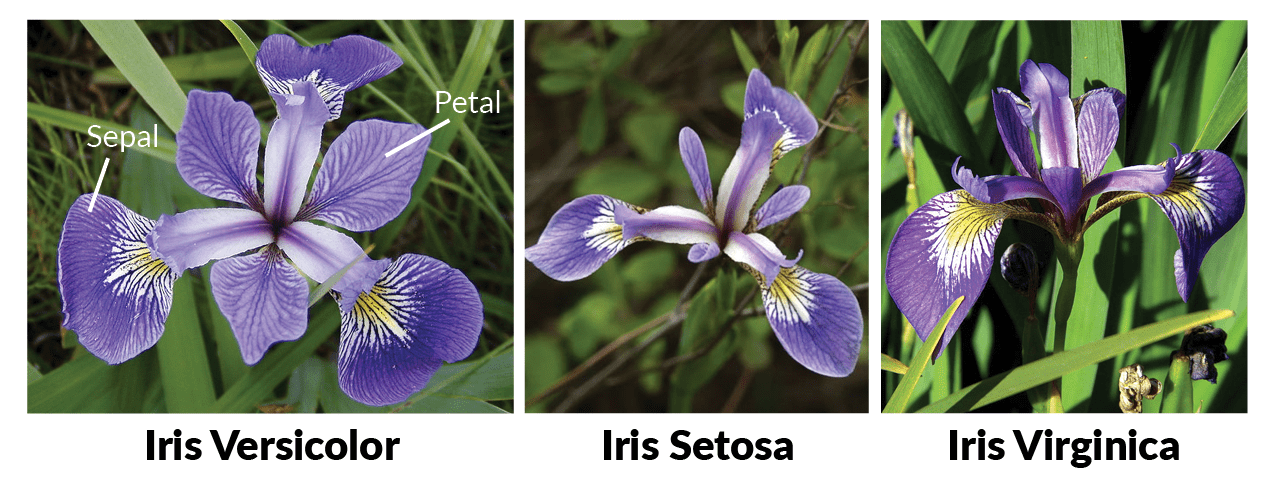

[source](http://www.lac.inpe.br/~rafael.santos/Docs/CAP394/WholeStory-Iris.html)

Nous allons maintenant importer les données.

In [2]:
data = sklearn.datasets.load_iris()

X = data['data']
y = data['target']

target_names = data['target_names']
feature_names = data['feature_names']

# Si on veut voir plus d'infos sur le jeu de données :
#print(data['DESCR'])

Maintenant que l'on connaît un peu mieux le jeu de données, on peut l'explorer en regardant directement chacune des données. En analysant rapidement les données, on remarque qu'il semble plus ou moins possible de séparer les différentes classes en fonction de la longueur du pétal (*petal length*) ou de la largeur du pétal (*petal width*).

In [3]:
# @title
pd.DataFrame(np.concatenate((X, target_names[y].reshape(-1,1)), axis=1), columns=feature_names+['Target'])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


On va maintenant visualiser le jeu de données en utilisant des graphiques. On compare les caractéristiques en paires.  Il est évident que la classe d'iris setosa est facilement séparable des deux autres classes.


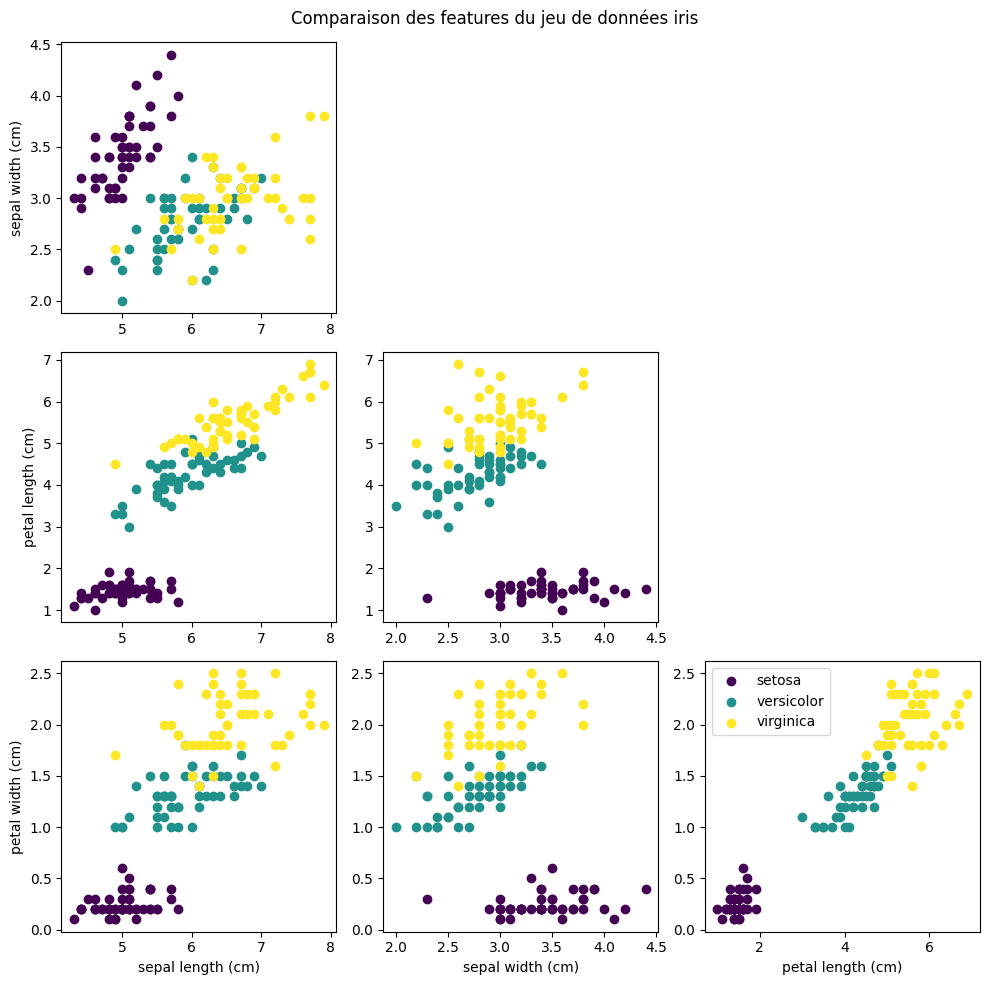

In [5]:
# @title
color=mcp.gen_color(cmap="viridis",n=3)

fig, axs = plt.subplots(3,3, figsize=(10,10))
axs[2,0].set_xlabel("sepal length (cm)")
axs[2,1].set_xlabel("sepal width (cm)")
axs[2,2].set_xlabel("petal length (cm)")

axs[0,0].set_ylabel("sepal width (cm)")
axs[1,0].set_ylabel("petal length (cm)")
axs[2,0].set_ylabel("petal width (cm)")

for i in range(2,-1,-1):
  for j in range(i+1):
    for k in range(3):
      axs[i,j].scatter(X[y==k,j], X[y==k,i+1], label=target_names[k], c=color[k])

axs[0,1].remove()
axs[0,2].remove()
axs[1,2].remove()

fig.suptitle("Comparaison des features du jeu de données iris")
plt.legend()
fig.tight_layout()
fig.show()

# Entraîner un modèle

Nous allons maintenant entraîner un arbre de décision. Un arbre de décision est un algorithme qui fait ses prédictions grâce à une suite de règles sur les caractéristiques.

On observe que la première règle de décision porte sur la longueur du pétal. Lorsque le pétal est plus petit qu'une certaine valeur, on sépare automatiquement l'entièreté des iris setosa. Toutefois, il n'est pas aussi facile de séparer les deux autres classes.

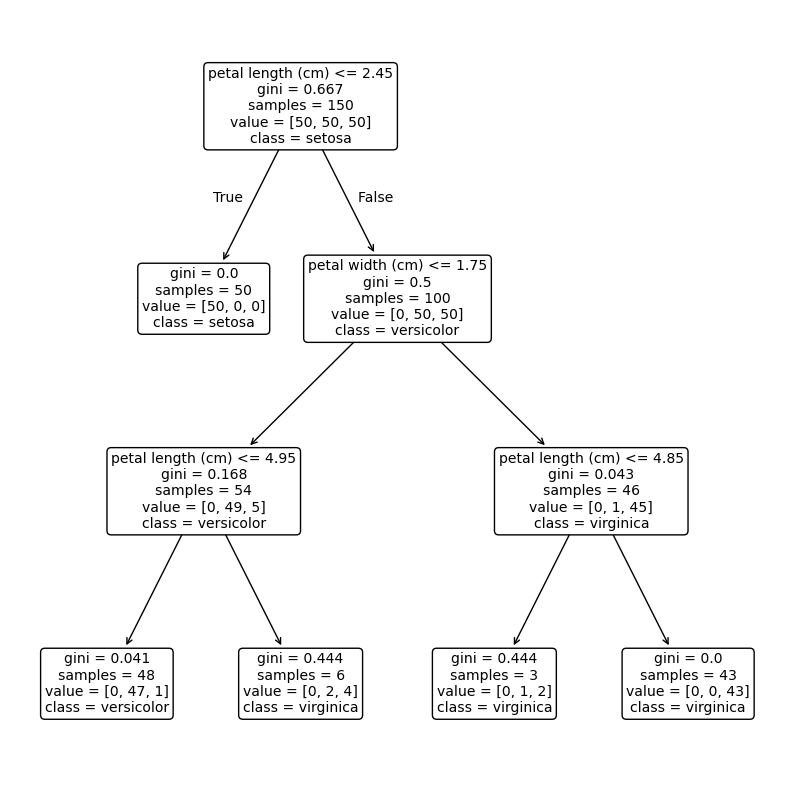

In [6]:
dt = sklearn.tree.DecisionTreeClassifier(max_depth=3,
                            criterion="gini",
                            min_samples_split=5,
                            min_samples_leaf=1,
                            random_state=42)

dt.fit(X,y)
plt.figure(figsize=(10,10))
sklearn.tree.plot_tree(dt,feature_names=feature_names, class_names=target_names, filled=False, rounded=True)
plt.show()

Avant même d'entraîner un arbre de décision, il est nécessaire de faire plusieurs choix, qui impacteront la qualité de l'arbre de décision sur les données. Par exemple, quelle devrait être la hauteur maximale de l'arbre. Est-ce qu'on devrait avoir seulement la racine, deux feuilles ou un arbre de profondeur 3 comme celui présenté plus haut ?

On va donc introduire un hyperparamètre appelé "max_depth", qui va permettre de décider au préalable la profondeur de l'arbre.

Je vous laisse jouer avec les curseurs ci-dessous pour essayer de mieux comprendre l'impact de ces hyperparamètres. Si cela vous intéresse, je vous invite à lire la [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier) pour mieux comprendre l'impact de chaque hyperparamètre.



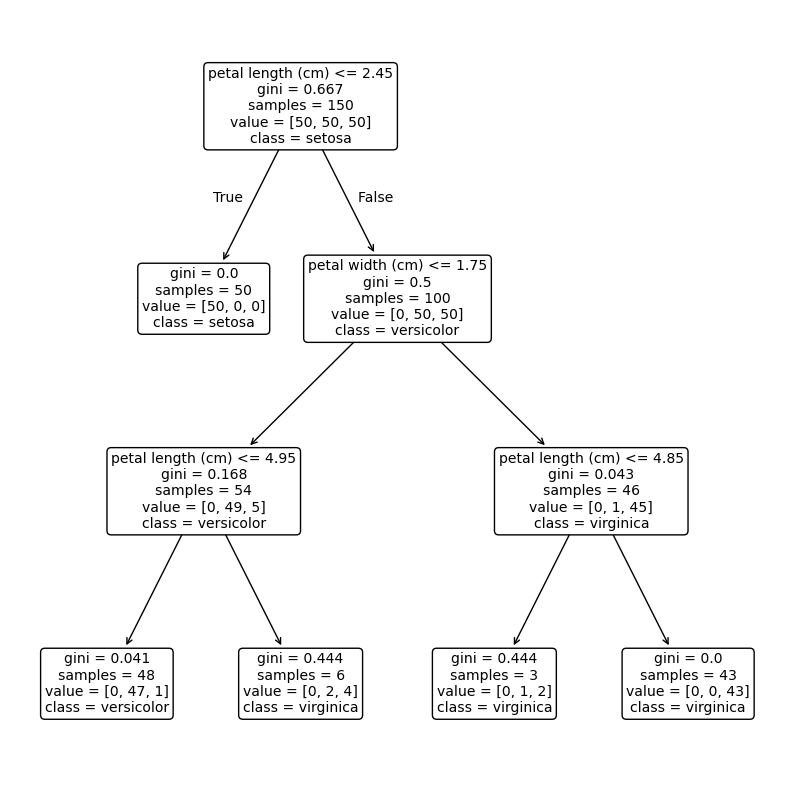

In [19]:
#@title { run: "auto" }
max_depth = 3 # @param {"type":"slider","min":1,"max":6,"step":1}
min_samples_split = 5 # @param {"type":"slider","min":2,"max":10,"step":1}
min_samples_leaf = 1 # @param {"type":"slider","min":1,"max":10,"step":1}
criterion = "gini" # @param ["gini","entropy"]

dt = sklearn.tree.DecisionTreeClassifier(max_depth=max_depth,
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            random_state=42)
dt.fit(X,y)
plt.figure(figsize=(10,10))
sklearn.tree.plot_tree(dt,feature_names=feature_names, class_names=target_names, filled=False, rounded=True)
plt.show()

Remettez les curseurs à 3, 5 et 1 et le critère à "gini".

En regardant l'arbre, on peut observer où et comment chacune des données ont été classifiées. On voit bien que toutes les iris setosa ont été classifiées correctement. Il est un peu plus difficile de le voir, mais 47 iris versicolor ont été classifiées correctement, et les 3 autres ont été classifiées en tant que des iris virginica. Finalement, il y a 49 iris virginica bien classifiées et une donnée mal classifiée comme une iris versicolor.

Notre arbre est petit et nous n'avons pas beaucoup de classe, donc il est facile de faire ces observations. Toutefois, pouvons nous le faire plus efficacement?

Oui, en utilisant une matrice de confusion.

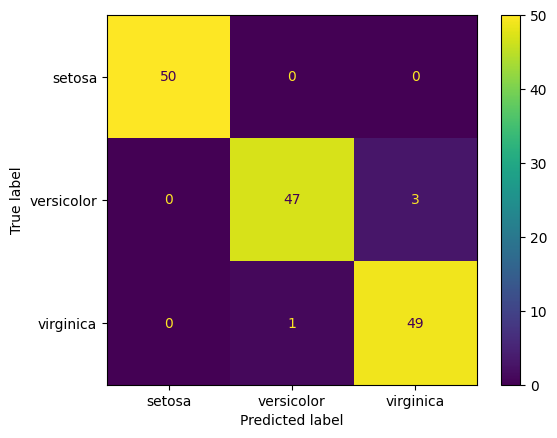

In [20]:
# @title
sklearn.metrics.ConfusionMatrixDisplay.from_estimator(dt, X, y, display_labels=target_names)
plt.show()

À partir de la matrice de confusion, on observe que quatre données sur 150 ont été mal classifiées. On a donc classifié correctement 97.33% des données, soit 146/150 données.

Cette valeur, que l'on a calculé intuitivement, se nomme l'*accuracy*. C'est une des métriques les plus connues en apprentissage supervisé, avec le *F1-score*.

In [ ]:
# @title
print(f"Accuracy : {100*sklearn.metrics.accuracy_score(dt.predict(X), y):.2f}%")
accuracy = (dt.predict(X) == y).mean()
print(f"Accuracy (manuel): {100*accuracy:.2f}%")

# Bonnes pratiques

Cette section porte sur les bonnes pratiques en apprentissage automatique.

Lorsque l'on entraîne un modèle, on souhaite qu'il performe aussi bien sur les données d'entraînement que sur des nouvelles données. On va donc se garder un jeu de données de test, ce qui nous permettra de vérifier les performances du modèles.

On va séparer notre jeu de données en deux. La première partie va servir de jeu de données d'entraînement et la deuxième partie va servir de jeu de données de test. Entraînons notre modèle, puis voyons son erreur en test.

In [ ]:
# @title
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

y_test = fonction_mystère(y_test)
y_test[::10]
dt = sklearn.tree.DecisionTreeClassifier(criterion='gini',
                              max_depth=None,
                              random_state=42)

dt.fit(X_train, y_train)
print(f"L'accuracy du meilleur modèle sur le jeu de données d'entraînement est : {100*dt.score(X_train, y_train):.2f}%",)
print(f"L'accuracy du meilleur modèle sur le jeu de données de test est : {100*dt.score(X_test, y_test):.2f}%",)

Surprenamment, notre modèle ne fonctionne pas bien sur le jeu de données de test. Qu'est-ce qu'il s'est passé? Il semble que notre modèle ait subi du surajustement (*overfitting*). C'est pour cela qu'il est important de se garder un jeu de données de test, car cela nous permet de vérifier que notre modèle n'a pas simplement appris à prédire les données, mais a appris la distribution des données.

Quand vous regarderez le code, vous remarquerez que j'ai manipulé les données pour obtenir ce résultat, mais il est fréquent d'obtenir des résultats similaires quand on travaille avec des vrais jeux de données.

Pour éviter ce genre de problème, on va généralement utiliser un ensemble de validation. L'ensemble de validation ne sera pas utilisé pour entraîner le modèle, mais servira à choisir la bonne combinaison d'hyperparamètres. On va donc :

1.   Entraîner chaque combinaison d'hyperparamètres
2.   Tester chaque modèle sur l'ensemble de validation
3.   Choisir le modèle ayant le meilleur résultat sur l'ensemble de validation
4.   Tester le modèle choisi sur l'ensemble de test

Mais quelles sont les hyperparamètres à utiliser?

Nous utiliserons une grille d'hyperparamètre. On va donc définir les différents valeurs de chaque hyperparamètre, puis on va tester chacune des combinaisons.

Mais on ne veut pas toujours choisir le même ensemble de validation pour évaluer les combinaisons d'hyperparamètres. Il pourrait être intéressant de tester les combinaisons d'hyperparamètres plusieurs fois, pour être sûr de choisir les meilleurs hyperparamètres.

On s'intéresse donc à la validation croisée. Pour ce faire, on sépare le jeu de données d'entraînement en $k$ plis (généralement 5 plis), on entraîne le modèle sur quatre des cinq plis, puis on valide le modèle sur le dernier plis. On refait cette opération quatre autres fois, en changeant le pli de validation à chaque fois.

Il y a une fonction très utile de `sklearn` qui nous offre une recherche par grille d'hyperparamètres avec validation croisée : `GridSearchCV`

In [ ]:
dt = sklearn.tree.DecisionTreeClassifier(random_state=42)

parameters = {'criterion':['gini', 'entropy'],
              'max_depth':np.arange(1,7),
              'min_samples_split':np.arange(2,6),
              'min_samples_leaf':np.arange(1,7)}
clf = sklearn.model_selection.GridSearchCV(dt, parameters, cv=5)

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
print(f"L'accuracy du meilleur modèle sur le jeu de données d'entraînement est : {100*clf.best_estimator_.score(X_train, y_train):.2f}%",)
print(f"L'accuracy du meilleur modèle sur le jeu de données de test est : {100*clf.best_estimator_.score(X_test, y_test):.2f}%",)
clf.best_estimator_

On remarque premièrement que les hyperparamètres choisis ne sont pas les mêmes. En effet, l'utilisation de plusieurs ensembles de validation permet d'obtenir des résultats plus robustes. De plus, on réentraîne sur l'entièreté du jeu de données d'entraînement, au lieu de réserver un ensemble de validation.

Les deux approches ont des avantages et des inconvénients. La validation croisée est généralement plus robuste, puisqu'on teste plusieurs combinaisons de données. Toutefois, la validation croisée prend beaucoup plus de temps à s'entraîner. Il est donc nécessaire de bien s'informer pour faire un bon choix.

# Exercices

Dans cette section, le but est de vous laisser pratiquer ce que vous avez appris. Avec un ensemble de données, vous allez :

- Découvrir les données
- Entrainer un modèle
- Évaluer la performance
- Trouver les meilleurs paramètres

Avec ce jeu de données, on veut prédir le "score" de qualité (0-10) d'un vin à partir de mesures comme le pH, la densité, l'acidité, et d'autres mesures chimiques. C'est évidement une valeur qu'on ne peut pas calculer, mais une valeur subjective et humaine. C'est un exemple parfait pour l'apprentissage automatique.

Faitez attention, il se peut qu'il y ait plus de vins d'une qualité qu'une autre. Il n'y aura aucun vin de qualité 0, par exemple. On peut dire que les données sont débalancées.


In [ ]:
# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets.values.reshape(-1,)

## Exercice 1 : Éxploration des données

J'ai mentionné plutôt que le jeu de données était débalancé, alors regardons un peu de quoi à l'air la distribution des étiquettes.

Indice : utilisez la fonction [`plt.hist`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html#matplotlib-pyplot-hist).

In [ ]:
# créer un histogramme de la distribution des étiquettes
plt.hist(y,bins=list(np.unique(y))+[10],align="left", rwidth=0.8)
plt.xlabel("Étiquettes du jeu de données")
plt.ylabel("Nombre d'étiquettes")
plt.title("Histogramme du nombre de classes")
plt.show()

In [ ]:
# @title Solution (exercice 1)
raise ErreurDansLeLaboratoire



plt.hist(y,bins=list(np.unique(y))+[10],align="left", rwidth=0.8)
plt.xlabel("Étiquettes du jeu de données")
plt.ylabel("Nombre d'étiquettes")
plt.title("Histogramme du nombre de classes")
plt.show()


## Exercice 2 : Un simple modèle

On sépare les données en un ensemble d'entraînement et un ensemble de test.

In [ ]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# @title Solution (Exercice 2)
raise ErreurDansLeLaboratoire


X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)


## Exercice 3

On veut entrainer un modèle de *K-plus-proches-voisins* (K-closest-neighbor), et on observe sa performance.

Utilisez le modèle `sklearn.neighbors.KNeighborsClassifier`. Voir [la documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier) pour plus de détails.

In [ ]:
# créer votre classifieur K-plus-proches-voisins

# entraîner votre modèle

# évaluer votre modèle
training_score = 0.0
test_score = 0.0
print(f"L'accuracy du meilleur modèle sur le jeu de données d'entraînement est : {100 * training_score:.2f}%",)
print(f"L'accuracy du meilleur modèle sur le jeu de données de test est : {100 * test_score:.2f}%",)

clf

In [ ]:
# @title Solution (Exercice 3)
raise ErreurDansLeLaboratoire



clf = sklearn.neighbors.KNeighborsClassifier()

clf.fit(X_train, y_train)

print(f"L'accuracy du meilleur modèle sur le jeu de données d'entraînement est : {100*clf.score(X_train, y_train):.2f}%",)
print(f"L'accuracy du meilleur modèle sur le jeu de données de test est : {100*clf.score(X_test, y_test):.2f}%",)
clf

## Exercice 4

On veut faire une recherche en grille de paramètres avec `GridSearchCV` pour construire le meilleur modèle. Ensuite, on veut l'entraîner et l'évaluer, comme avant.

Utilisez `sklearn.model_selection.GridSearchCV` pour faire la recherche de paramètres. Allez voir [la documentation de KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier) pour les descriptions des paramètres.

In [ ]:
# créer le classifieur K-plus-proches-voisins

# définir les paramètres à essayer

# définir la recherche en grille (GridSearchCV)

# entrainer le modèle avec la recherche en grille

# évaluer le meilleur modèle
best_train_score = 0.0
best_test_score = 0.0
print(f"L'accuracy du meilleur modèle sur le jeu de données d'entraînement est : {100*best_train_score:.2f}%",)
print(f"L'accuracy du meilleur modèle sur le jeu de données de test est : {100*best_test_score:.2f}%",)


In [ ]:
# @title Solution (Exercice 4)
raise ErreurDansLeLaboratoire



clf = sklearn.neighbors.KNeighborsClassifier()

parameters = {'n_neighbors':[1,2,5,10,20,50],
              'p':[1,2,3],
              'weights':['uniform', 'distance']}
gs = sklearn.model_selection.GridSearchCV(dt, parameters, cv=4)

gs.fit(X_train, y_train)
print(f"L'accuracy du meilleur modèle sur le jeu de données d'entraînement est : {100*gs.best_estimator_.score(X_train, y_train):.2f}%",)
print(f"L'accuracy du meilleur modèle sur le jeu de données de test est : {100*gs.best_estimator_.score(X_test, y_test):.2f}%",)
gs.best_estimator_